In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from lib.dgm import Net_DGM


# EX3: Deep Galerkin Method for a linear PDE
# SCDAA Coursework 2025-26
#
# PDE:
#   u_t + 1/2 tr(sigma sigma^T Hess_x u)
#       + (grad_x u)^T Hx + (grad_x u)^T M alpha
#       + x^T C x + alpha^T D alpha = 0,
#   on [0,T) x R^2
#
# Terminal condition:
#   u(T,x) = x^T R x
#
# The Monte Carlo benchmark uses the constant control alpha=(1,1)^T.
# This file follows the parameter choice used in EX1_1.



# Reproducibility / device
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



# Model parameters (same style as EX1_1)
T = 1.0

H = torch.tensor([[0.1, 0.0],
                  [0.0, 0.2]], dtype=torch.float32, device=device)
M = torch.eye(2, dtype=torch.float32, device=device)
C = torch.eye(2, dtype=torch.float32, device=device)
D = torch.eye(2, dtype=torch.float32, device=device)
R = torch.eye(2, dtype=torch.float32, device=device)
sigma = 0.3 * torch.eye(2, dtype=torch.float32, device=device)

alpha = torch.tensor([1.0, 1.0], dtype=torch.float32, device=device)
sigma_sigma_T = sigma @ sigma.T
alpha_D_alpha = alpha @ D @ alpha



# Terminal condition u(T,x) = x^T R x
def terminal_value(x):
    # x: (batch, 2)
    return torch.sum((x @ R) * x, dim=1, keepdim=True)



# PDE residual
def pde_residual(model, t, x):
    # Enable autograd for derivatives
    t = t.clone().detach().requires_grad_(True)
    x = x.clone().detach().requires_grad_(True)

    u = model(t, x)  # (batch, 1)

    # Time derivative u_t
    u_t = torch.autograd.grad(
        u, t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # Spatial gradient grad_x u = (u_x1, u_x2)
    grad_u = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]  # (batch, 2)

    # Hessian of u with respect to x
    # Build Hessian batch-wise as shape (batch, 2, 2)
    hessian_rows = []
    for i in range(2):
        grad_component = grad_u[:, i:i+1]
        second_derivs = torch.autograd.grad(
            grad_component, x,
            grad_outputs=torch.ones_like(grad_component),
            create_graph=True
        )[0]  # (batch, 2)
        hessian_rows.append(second_derivs)

    hessian = torch.stack(hessian_rows, dim=1)  # (batch, 2, 2)

    # Diffusion term: 1/2 tr(sigma sigma^T Hessian)
    diffusion = 0.5 * torch.einsum('ij,bij->b', sigma_sigma_T, hessian).unsqueeze(1)

    # Drift term 1: (grad u)^T Hx
    Hx = x @ H.T
    drift_1 = torch.sum(grad_u * Hx, dim=1, keepdim=True)

    # Drift term 2: (grad u)^T M alpha
    M_alpha = M @ alpha
    drift_2 = torch.sum(grad_u * M_alpha.unsqueeze(0), dim=1, keepdim=True)

    # Running cost: x^T C x + alpha^T D alpha
    x_C_x = torch.sum((x @ C) * x, dim=1, keepdim=True)
    running_cost = x_C_x + alpha_D_alpha.view(1, 1)

    residual = u_t + diffusion + drift_1 + drift_2 + running_cost
    return residual



# Loss for Deep Galerkin Method
def dgm_loss(model, batch_size_interior=256, batch_size_terminal=256, x_low=-3.0, x_high=3.0):
    # Interior samples: t ~ U[0,T], x ~ U([x_low,x_high]^2)
    t_interior = T * torch.rand(batch_size_interior, 1, device=device)
    x_interior = x_low + (x_high - x_low) * torch.rand(batch_size_interior, 2, device=device)

    residual = pde_residual(model, t_interior, x_interior)
    loss_pde = torch.mean(residual ** 2)

    # Terminal samples: x ~ U([x_low,x_high]^2)
    t_terminal = T * torch.ones(batch_size_terminal, 1, device=device)
    x_terminal = x_low + (x_high - x_low) * torch.rand(batch_size_terminal, 2, device=device)

    pred_terminal = model(t_terminal, x_terminal)
    true_terminal = terminal_value(x_terminal)
    loss_terminal = torch.mean((pred_terminal - true_terminal) ** 2)

    loss = loss_pde + loss_terminal
    return loss, loss_pde, loss_terminal



# Monte Carlo benchmark for the constant control alpha
# SDE: dX = (H X + M alpha) dt + sigma dW
@torch.no_grad()
def mc_value_constant_alpha(t0, x0, N=1000, MC=5000):
    """
    Monte Carlo estimate of the value under constant control alpha=(1,1)^T.

    Inputs
    t0 : float
    Initial time in [0,T].
    x0 : torch tensor of shape (2,)
    Initial state.
    N : int
    Number of time steps.
    MC : int
    Number of Monte Carlo paths.
    """
    if t0 >= T:
        x0 = x0.to(device)
        return torch.sum((x0 @ R) * x0).item()

    dt = (T - t0) / N
    sqrt_dt = torch.sqrt(torch.tensor(dt, dtype=torch.float32, device=device))

    X = x0.to(device).unsqueeze(0).repeat(MC, 1)
    running_cost = torch.zeros(MC, dtype=torch.float32, device=device)
    const_cost = alpha @ D @ alpha

    for _ in range(N):
        drift = X @ H.T + (M @ alpha).unsqueeze(0)
        dW = sqrt_dt * torch.randn(MC, 2, device=device)

        running_cost += (torch.sum((X @ C) * X, dim=1) + const_cost) * dt
        X = X + drift * dt + dW @ sigma.T

    terminal_cost = torch.sum((X @ R) * X, dim=1)
    return torch.mean(running_cost + terminal_cost).item()


# Evaluation against Monte Carlo benchmark
@torch.no_grad()
def evaluate_error(model, test_points, N_mc=1000, MC_mc=5000):
    errors = []
    preds = []
    truths = []

    model.eval()

    for t0, x0 in test_points:
        t_tensor = torch.tensor([[t0]], dtype=torch.float32, device=device)
        x_tensor = torch.tensor([x0], dtype=torch.float32, device=device)

        pred = model(t_tensor, x_tensor).item()
        truth = mc_value_constant_alpha(
            t0=t0,
            x0=torch.tensor(x0, dtype=torch.float32),
            N=N_mc,
            MC=MC_mc,
        )

        preds.append(pred)
        truths.append(truth)
        errors.append(abs(pred - truth))

    mean_abs_error = sum(errors) / len(errors)
    return mean_abs_error, preds, truths




Using device: cpu


Starting training...

Epoch  200 | loss = 0.162428 | pde = 0.093879 | terminal = 0.068549 | MC mean abs error = 0.285075
Epoch  400 | loss = 0.049908 | pde = 0.033115 | terminal = 0.016793 | MC mean abs error = 0.050750
Epoch  600 | loss = 0.045974 | pde = 0.040214 | terminal = 0.005760 | MC mean abs error = 0.047943
Epoch  800 | loss = 0.011581 | pde = 0.007350 | terminal = 0.004231 | MC mean abs error = 0.043251
Epoch 1000 | loss = 0.050915 | pde = 0.043847 | terminal = 0.007068 | MC mean abs error = 0.060840
Epoch 1200 | loss = 0.007821 | pde = 0.004164 | terminal = 0.003657 | MC mean abs error = 0.052369
Epoch 1400 | loss = 0.018966 | pde = 0.012837 | terminal = 0.006129 | MC mean abs error = 0.042175
Epoch 1600 | loss = 0.021869 | pde = 0.008064 | terminal = 0.013805 | MC mean abs error = 0.026524
Epoch 1800 | loss = 0.019513 | pde = 0.016545 | terminal = 0.002968 | MC mean abs error = 0.087275
Epoch 2000 | loss = 0.042725 | pde = 0.027789 | terminal = 0.014936 | MC mean abs error

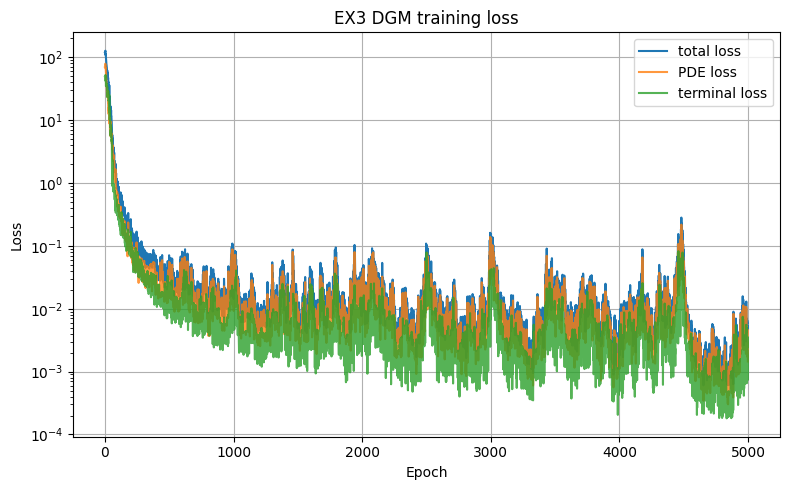

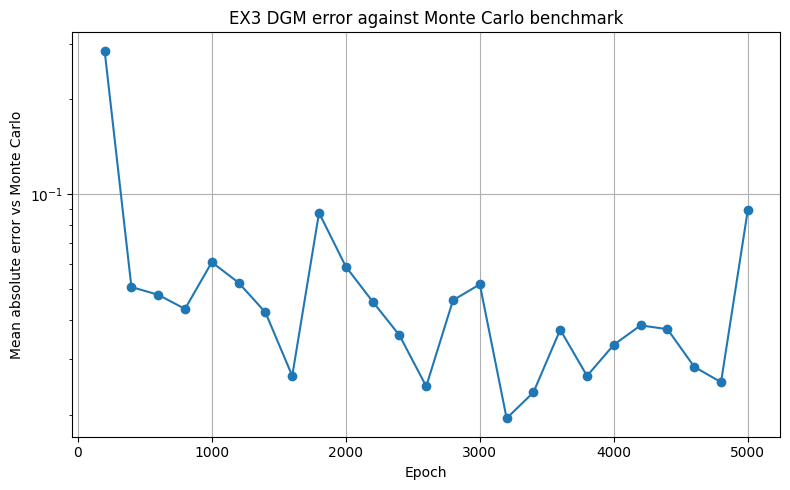


Final comparison on fixed test points:
Point 1: t=0.00, x=[0.0, 0.0], network=5.335045, MC=5.380273, abs error=0.045228
Point 2: t=0.00, x=[1.0, 1.0], network=17.689333, MC=17.843824, abs error=0.154491
Point 3: t=0.25, x=[1.0, -1.0], network=7.157750, MC=7.239063, abs error=0.081313
Point 4: t=0.50, x=[2.0, 0.5], network=12.021542, MC=12.125651, abs error=0.104110
Point 5: t=0.75, x=[-1.5, 1.0], network=4.694791, MC=4.729384, abs error=0.034593

Final mean absolute error: 0.083947


In [2]:

# Main training routine
def main():
    model = Net_DGM(dim_x=2, dim_S=100, activation="Tanh").to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Training configuration
    num_epochs = 5000
    batch_size_interior = 256
    batch_size_terminal = 256

    # Evaluate error only at intervals (MC is expensive)
    eval_every = 200

    # Fixed test points for reproducible error tracking
    test_points = [
        (0.00, [0.0, 0.0]),
        (0.00, [1.0, 1.0]),
        (0.25, [1.0, -1.0]),
        (0.50, [2.0, 0.5]),
        (0.75, [-1.5, 1.0]),
    ]

    loss_history = []
    loss_pde_history = []
    loss_terminal_history = []
    error_history = []
    eval_epochs = []

    print("Starting training...\n")

    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad()

        loss, loss_pde, loss_terminal = dgm_loss(
            model,
            batch_size_interior=batch_size_interior,
            batch_size_terminal=batch_size_terminal,
            x_low=-3.0,
            x_high=3.0,
        )

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
        loss_pde_history.append(loss_pde.item())
        loss_terminal_history.append(loss_terminal.item())

        if epoch % eval_every == 0:
            mean_abs_error, preds, truths = evaluate_error(
                model,
                test_points,
                N_mc=1000,
                MC_mc=5000,
            )
            error_history.append(mean_abs_error)
            eval_epochs.append(epoch)

            print(
                f"Epoch {epoch:4d} | "
                f"loss = {loss.item():.6f} | "
                f"pde = {loss_pde.item():.6f} | "
                f"terminal = {loss_terminal.item():.6f} | "
                f"MC mean abs error = {mean_abs_error:.6f}"
            )

    # Plot 1: training loss
    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, label="total loss")
    plt.plot(loss_pde_history, label="PDE loss", alpha=0.8)
    plt.plot(loss_terminal_history, label="terminal loss", alpha=0.8)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("EX3 DGM training loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("EX3_training_loss.png", dpi=200)
    plt.show()

    
    # Plot 2: error against Monte Carlo
    plt.figure(figsize=(8, 5))
    plt.plot(eval_epochs, error_history, marker="o")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Mean absolute error vs Monte Carlo")
    plt.title("EX3 DGM error against Monte Carlo benchmark")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("EX3_mc_error.png", dpi=200)
    plt.show()

    
    # Final comparison on test points
    print("\nFinal comparison on fixed test points:")
    final_error, preds, truths = evaluate_error(
        model,
        test_points,
        N_mc=2000,
        MC_mc=10000,
    )

    for i, ((t0, x0), pred, truth) in enumerate(zip(test_points, preds, truths)):
        print(
            f"Point {i+1}: t={t0:.2f}, x={x0}, "
            f"network={pred:.6f}, MC={truth:.6f}, abs error={abs(pred-truth):.6f}"
        )

    print(f"\nFinal mean absolute error: {final_error:.6f}")


if __name__ == "__main__":
    main()